# Standard Monte Carlo Sampling Demo

In [1]:
import jax
import jax.numpy as jnp

import sys
sys.path.append('../')

import pyHaiCS as haics
from pyHaiCS.utils.metrics import geyerESS, multiESS, codaESS
from pyHaiCS.samplers.standard import rejection_sampling

class ProposalDistribution:
    def __init__(self):
        pass

    def sample(self, key, shape=()):
        """
        Sample from the proposal distribution.
        """
        return jax.random.uniform(key, shape=shape)

    def pdf(self, x):
        return jnp.where((x >= 0) & (x <= 1), 1.0, 0.0)

# Define the target and proposal PDFs using JAX
def target_pdf(x):
    return jnp.sin(2 * jnp.pi * x) + 1

samples = rejection_sampling(proposal = ProposalDistribution(), target = target_pdf, M = 2.0, n_samples = 100_000, n_chains = 4)

Running Rejection Sampler...
         Num. Chains          |              4               
         Num. Samples         |            100000            
       Proposal Bound M       |             2.0              


/var/folders/8_/q_t08kw12q976jfrgvgxlypw0000gn/T/ipykernel_5297/2535567390.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  plt.plot(x, y / np.trapz(y, x), 'r-', label='Target PDF (normalized)')


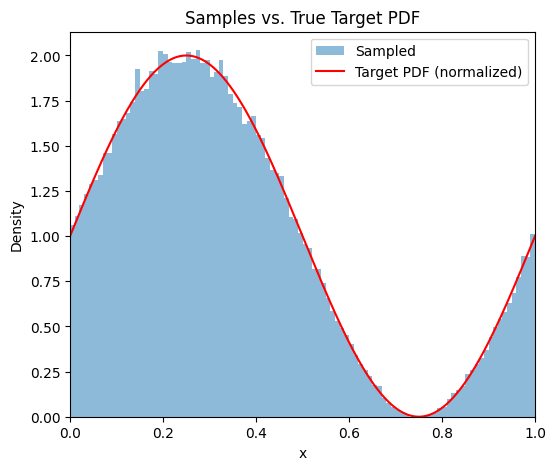

In [2]:
import matplotlib.pyplot as plt
import numpy as np

x = jnp.linspace(0, 1, 3000)
y = target_pdf(x)

plt.figure(figsize=(6, 5))
# Plot histogram of samples (flattened across chains)
plt.hist(samples[0], bins=100, density=True, alpha=0.5, label='Sampled')
# Plot true target pdf
plt.plot(x, y / np.trapz(y, x), 'r-', label='Target PDF (normalized)')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.xlim(0, 1)
plt.title('Samples vs. True Target PDF')
plt.show()

In [3]:
from pyHaiCS.samplers.standard import importance_sampling

samples, weights = importance_sampling(proposal = ProposalDistribution(), target = target_pdf, n_samples = 1_000_000, n_chains = 4)

Running Importance Sampler...
         Num. Chains          |              4               
         Num. Samples         |           1000000            


In [4]:
# Resample using the importance weights to obtain samples from the target distribution
def resample_with_weights(samples, weights, key):
    n_chains, n_samples = samples.shape
    resampled = []
    for i in range(n_chains):
        idx = jax.random.choice(key, n_samples, shape=(n_samples,), p=weights[i], replace=True)
        resampled.append(samples[i][idx])
    return jnp.stack(resampled)

# Generate a new random key for resampling
resample_key = jax.random.PRNGKey(42)
samples = resample_with_weights(samples, weights, resample_key)

/var/folders/8_/q_t08kw12q976jfrgvgxlypw0000gn/T/ipykernel_5297/1709457438.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  plt.plot(x, y / np.trapz(y, x), 'r-', label='Target PDF (normalized)')


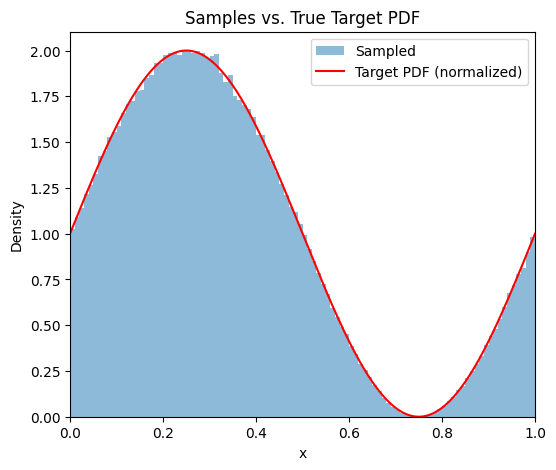

In [5]:
import matplotlib.pyplot as plt
import numpy as np

x = jnp.linspace(0, 1, 3000)
y = target_pdf(x)

plt.figure(figsize=(6, 5))
# Plot histogram of samples
plt.hist(samples[0], bins=100, density=True, alpha=0.5, label='Sampled')
# Plot true target pdf
plt.plot(x, y / np.trapz(y, x), 'r-', label='Target PDF (normalized)')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.xlim(0, 1)
plt.title('Samples vs. True Target PDF')
plt.show()